# Regression

**Business Objective:**

The primary objective of this project is to build a machine learning model that accurately predicts CO₂ emissions based on various vehicle engine features such as engine size, cylinders, fuel consumption, and transmission type. This analysis helps identify the key factors affecting emissions and supports the development of more fuel-efficient and environmentally friendly vehicles.


**Data Set Details:**

The file contains the data for this example. Here the number of variables (columns) is 12, and the number
of instances (rows) is 7385. In that way, this problem has the 12 following variables:
make, car brand under study.
model, the specific model of the car.
vehicle_class, car body type of the car.
engine_size, size of the car engine, in Liters.
cylinders, number of cylinders.
transmission, &quot;A&quot; for`Automatic&#39;, &quot;AM&quot; for ``Automated manual&#39;, &quot;AS&quot; for &#39;Automatic with select shift&#39;,
&quot;AV&quot; for &#39;Continuously variable&#39;, &quot;M&quot; for &#39;Manual&#39;.
fuel_type, &quot;X&quot; for &#39;Regular gasoline&#39;, &quot;Z&quot; for &#39;Premium gasoline&#39;, &quot;D&quot; for &#39;Diesel&#39;, &quot;E&quot; for &#39;Ethanol (E85)&#39;,
&quot;N&quot; for &#39;Natural gas&#39;.
fuel_consumption_city, City fuel consumption ratings, in liters per 100 kilometers.
fuel_consumption_hwy, Highway fuel consumption ratings, in liters per 100 kilometers.
fuel_consumption_comb(l/100km), the combined fuel consumption rating (55% city, 45% highway), in
L/100 km.
fuel_consumption_comb(mpg), the combined fuel consumption rating (55% city, 45% highway), in
miles per gallon (mpg).
co2_emissions, the tailpipe emissions of carbon dioxide for combined city and highway driving, in grams
per kilometer.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [58]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir('/content/drive/MyDrive/'))
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/'))

df = pd.read_csv('/content/drive/MyDrive/co2_emissions.csv', encoding='latin1')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['IMG-20210901-WA0007.jpg', 'Dharani_Resume.pdf', 'Dharani CV.docx', 'CLS_9792.JPG', 'Paris Booking.com_ Confirmation.pdf', 'sales_data_with_discounts.csv', 'Copy of Book2.xlsx', 'Cleaned Dataset.xlsx', '7th question.xlsx', 'croudfunding dashboard (1).xlsx', 'croudfunding dashboard.xlsx', 'Book1.xlsx', '2 question.xlsx', 'question2.xlsx', 'Tableau D (1).twbx', 'Tableau D.twb', 'extract tabl.hyper', 'Tableau D.twbx', 'Category.xlsx', 'Location.xlsx', 'Project.xlsx', 'Creator.xlsx', 'CROUDFUNDING DASHBOARD PBI (1) 1.pbix', 'Resumes', 'ColabNotebooks', 'cleaned_nlp_project_data.csv', 'Sentimental_Analysis(P667)_(7_5_2026).ipynb', 'SA_Final.pptx', 'WhatsApp Video 2026-05-15 at 16.34.59.mp4', 'sentimental_analysis(p667)_(7_5_2026).py', 'Colab Notebooks', 'online_course_recommendation.csv', 'Untitled map.gmap', 'co2_emissions.csv', 'Approvals - Prestige Pallavaram 

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
0,ACURA,ILX,COMPACT,2.0,4,AS,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS,Z,12.1,8.7,10.6,27,244


# EDA

## Data Cleaning

In [59]:
df

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
0,ACURA,ILX,COMPACT,2.0,4,AS,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS,Z,11.2,8.3,9.9,29,232


In [60]:
df.shape

(7385, 12)

In [61]:
df.columns

Index(['make', 'model', 'vehicle_class', 'engine_size', 'cylinders',
       'transmission', 'fuel_type', 'fuel_consumption_city',
       'fuel_consumption_hwy', 'fuel_consumption_comb(l/100km)',
       'fuel_consumption_comb(mpg)', 'co2_emissions'],
      dtype='object')

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   make                            7385 non-null   object 
 1   model                           7385 non-null   object 
 2   vehicle_class                   7385 non-null   object 
 3   engine_size                     7385 non-null   float64
 4   cylinders                       7385 non-null   int64  
 5   transmission                    7385 non-null   object 
 6   fuel_type                       7385 non-null   object 
 7   fuel_consumption_city           7385 non-null   float64
 8   fuel_consumption_hwy            7385 non-null   float64
 9   fuel_consumption_comb(l/100km)  7385 non-null   float64
 10  fuel_consumption_comb(mpg)      7385 non-null   int64  
 11  co2_emissions                   7385 non-null   int64  
dtypes: float64(4), int64(3), object(5)

The output shows that the dataset has 7385 entries and 12 columns. All columns are non-null, indicating no missing values at this stage. The data types are appropriate for further analysis and modeling.

In [63]:
df.describe()

,engine_size,cylinders,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


The output provides a statistical summary of the numerical columns:

*   engine_size: Ranges from 0.9 to 8.4 liters, with a mean of ~3.16. This suggests a good variety of engine sizes.
*   cylinders: Most cars have 4 or 6 cylinders, but there are vehicles with up to 16 cylinders and min is 3.
*   The combined fuel consumption (L/100km) has a mean of ~10.97.
*   co2_emissions: This is our target variable, ranging from 96 g/km to 522 g/km, with a mean of ~250.58 g/km. **The standard deviation of ~58.5 indicates a spread in emissions**.

There are no obvious anomalies from this summary, and the ranges seem reasonable for car specifications.

In [64]:
# Check for missing values in each column
print('\nMissing values per column:')
print(df.isnull().sum())


Missing values per column:
make                              0
model                             0
vehicle_class                     0
engine_size                       0
cylinders                         0
transmission                      0
fuel_type                         0
fuel_consumption_city             0
fuel_consumption_hwy              0
fuel_consumption_comb(l/100km)    0
fuel_consumption_comb(mpg)        0
co2_emissions                     0
dtype: int64


In [65]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f'\nNumber of duplicate rows: {duplicate_rows}')

# If duplicates exist, remove them
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print('Duplicate rows removed.')
    print(f'DataFrame shape after removing duplicates: {df.shape}')


Number of duplicate rows: 1112
Duplicate rows removed.
DataFrame shape after removing duplicates: (6273, 12)


Identified **1112 duplicate rows** and successfully removed them. This is an important data cleaning step as duplicates can skew analysis and model training.

The DataFrame size reduced from 7385 to 6273 rows, ensuring that each observation is unique.

In [66]:
df

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
0,ACURA,ILX,COMPACT,2.0,4,AS,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS,Z,11.2,8.3,9.9,29,232


In [67]:
# Display descriptive statistics for numerical columns
print('\nDescriptive statistics for numerical columns:')
display(df.describe())


Descriptive statistics for numerical columns:


,engine_size,cylinders,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
count,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000
mean,3.163000,5.620596,12.615591,9.073426,11.022111,27.395026,251.247250
std,1.365294,1.846424,3.550572,2.277893,2.945028,7.225472,59.235396
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.700000,10.300000,12.700000,32.000000,289.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


## Data Exploration and Visualization

**Distribution of Numerical Features (Histograms)**

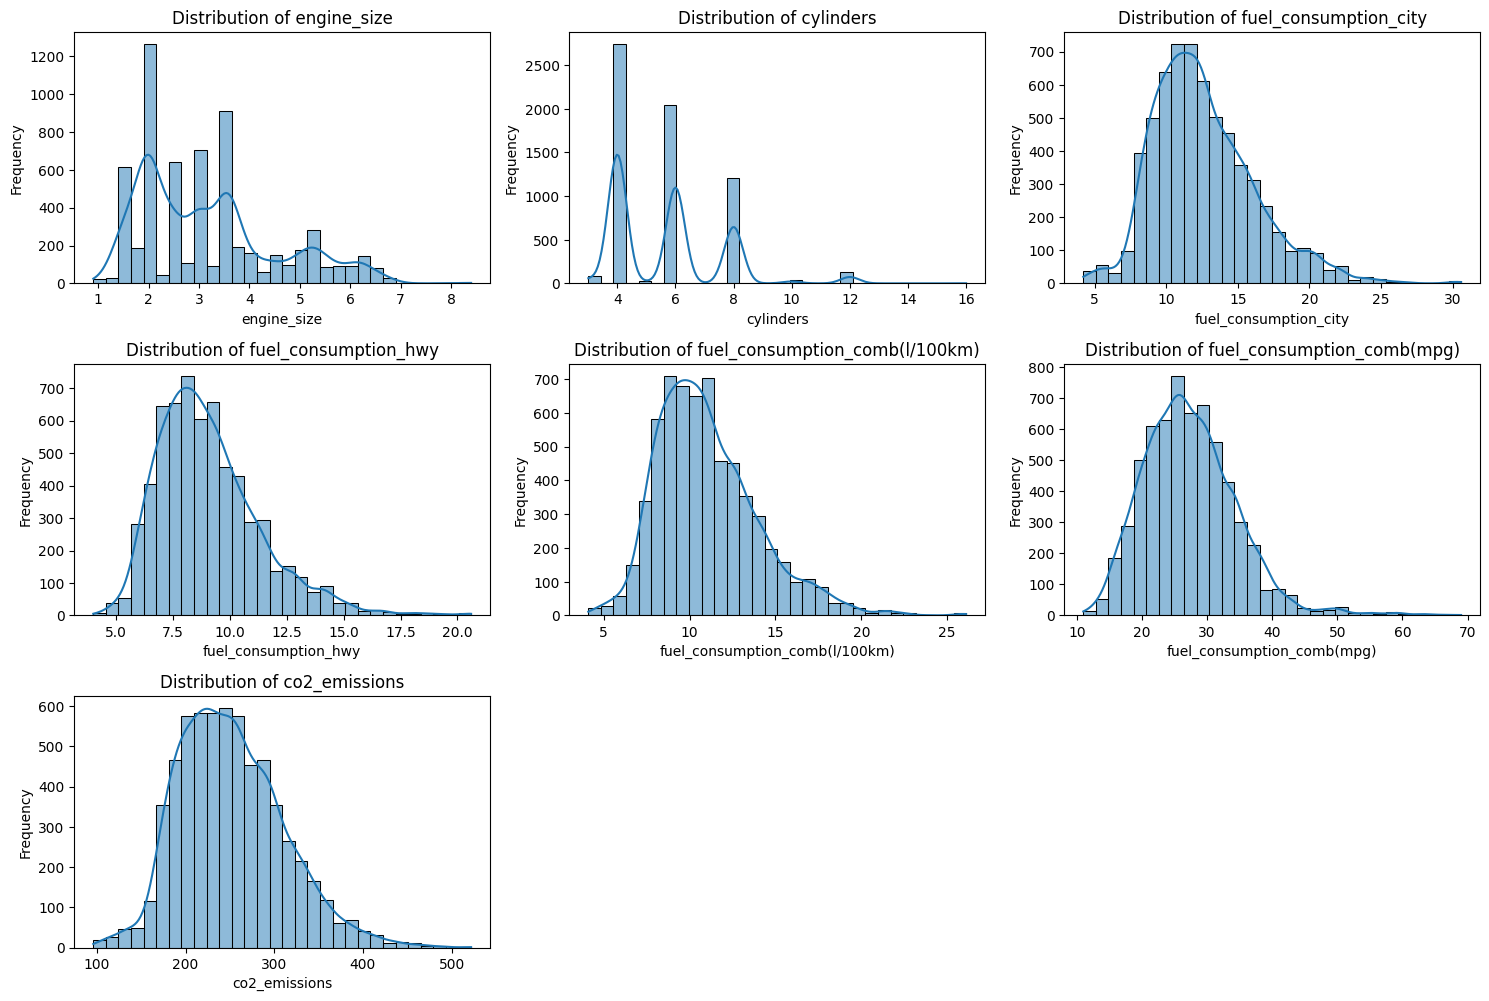

In [68]:
# Select only numerical columns for histograms
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms for all numerical features
fig = plt.figure(figsize=(15, 13))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

*   engine_size: Appears somewhat right-skewed, with a peak around 2 liters, and a secondary peak around 3.5 liters.
*   cylinders: Shows discrete peaks at 4, 6, and 8 cylinders, which is expected for this feature.
*   **`fuel_consumption_city`, `fuel_consumption_hwy`, `fuel_consumption_comb(l/100km)`**: All exhibit right-skewed distributions, with a long tail towards higher consumption values.
*   fuel_consumption_comb(mpg): This distribution appears more symmetrical, possibly due to its inverse relationship with L/100km measurements.
*   co2_emissions: The target variable is also right-skewed, peaking around 200-250 g/km.

These distributions give a good initial understanding of the data's spread and central tendencies, and highlight potential skewness in several features.

**Outlier Detection for Numerical Features (Box Plots)**

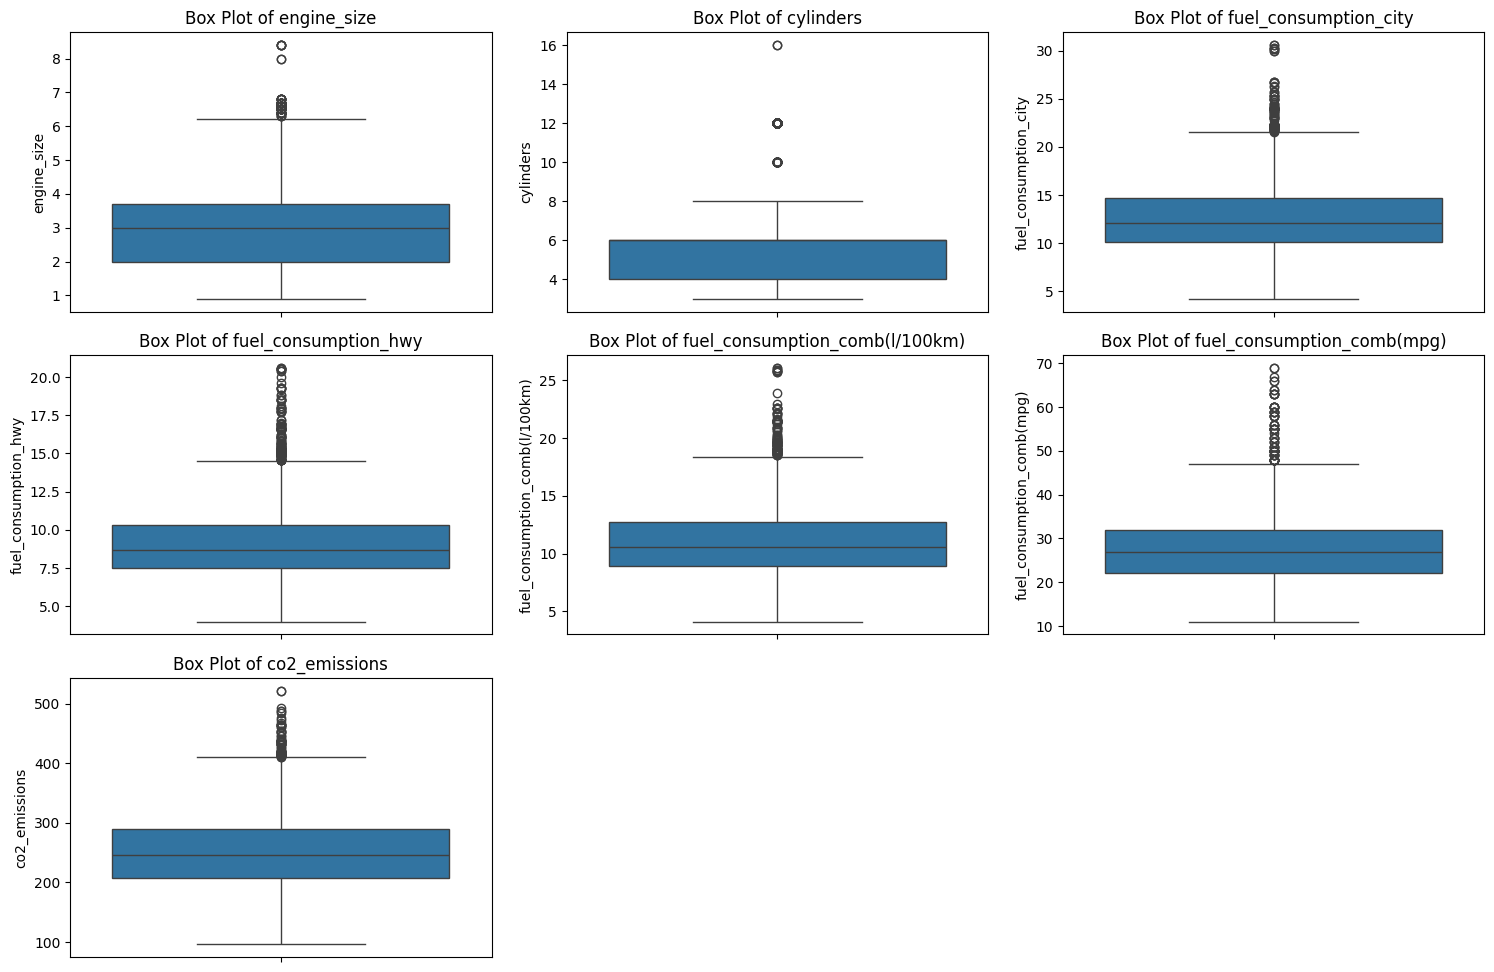

In [69]:
# Plot box plots for all numerical features to identify outliers
fig = plt.figure(figsize=(15, 13))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

All fuel consumption metrics and co2_emissions display a significant number of outliers on the higher side. This suggests that some vehicles have exceptionally high fuel consumption and CO2 emissions.

fuel_consumption_comb(mpg) has outliers on both high and low sides, corresponding to efficient and inefficient vehicles, respectively.

**Enhanced Scatter Plot: Engine Size vs CO₂ Emissions by Cylinders**

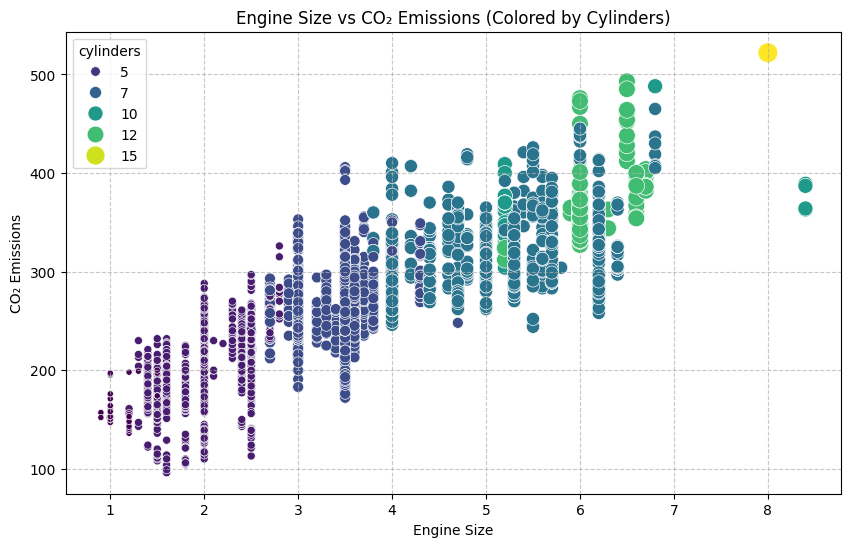

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='engine_size', y='co2_emissions', hue='cylinders', data=df, palette='viridis', size='cylinders', sizes=(20, 200))
plt.title('Engine Size vs CO₂ Emissions (Colored by Cylinders)')
plt.xlabel('Engine Size')
plt.ylabel('CO₂ Emissions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot clearly shows a strong positive correlation between engine_size and co2_emissions.

As engine size increases, CO₂ emissions generally increase.

*   Vehicles with more cylinders tend to have larger engine sizes and consequently higher CO₂ emissions.
*   The relationship appears roughly linear, but with some spread, suggesting other factors also influence CO₂ emissions.

This confirms `engine_size` and `cylinders` are important predictors for `co2_emissions`.

**Fuel Consumption vs CO₂ Emissions**

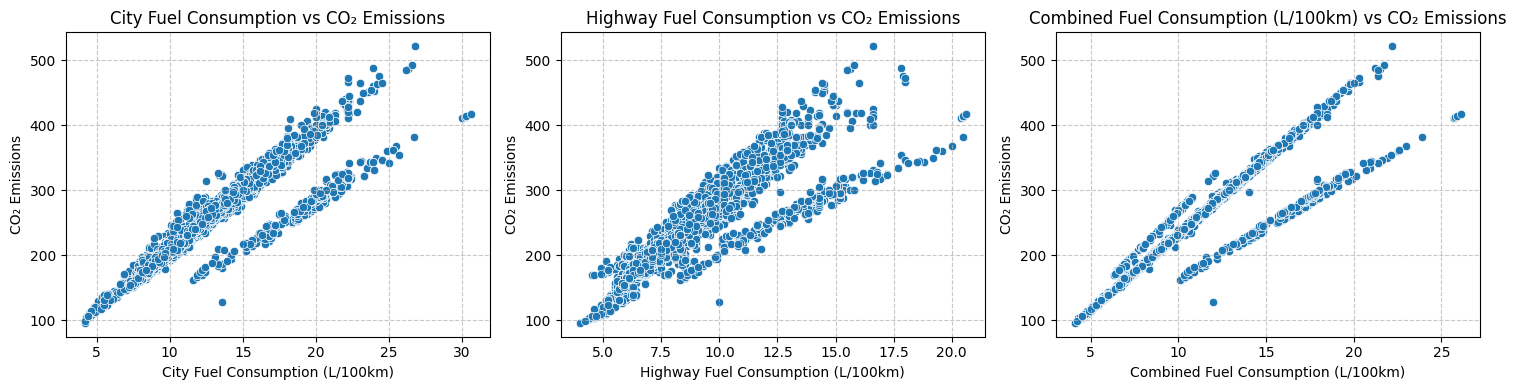

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x='fuel_consumption_city', y='co2_emissions', data=df, ax=axes[0])
axes[0].set_title('City Fuel Consumption vs CO₂ Emissions')
axes[0].set_xlabel('City Fuel Consumption (L/100km)')
axes[0].set_ylabel('CO₂ Emissions')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(x='fuel_consumption_hwy', y='co2_emissions', data=df, ax=axes[1])
axes[1].set_title('Highway Fuel Consumption vs CO₂ Emissions')
axes[1].set_xlabel('Highway Fuel Consumption (L/100km)')
axes[1].set_ylabel('CO₂ Emissions')
axes[1].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(x='fuel_consumption_comb(l/100km)', y='co2_emissions', data=df, ax=axes[2])
axes[2].set_title('Combined Fuel Consumption (L/100km) vs CO₂ Emissions')
axes[2].set_xlabel('Combined Fuel Consumption (L/100km)')
axes[2].set_ylabel('CO₂ Emissions')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

This demonstrate a very strong positive linear relationship.

As any of the fuel consumption metrics increase, `co2_emissions` also increase proportionally.

The correlation appears almost perfect, suggesting that fuel consumption is a primary driver of CO₂ emissions. This is expected, as CO₂ emissions are a direct byproduct of fuel combustion.

**Transmission Type vs CO₂ Emissions**

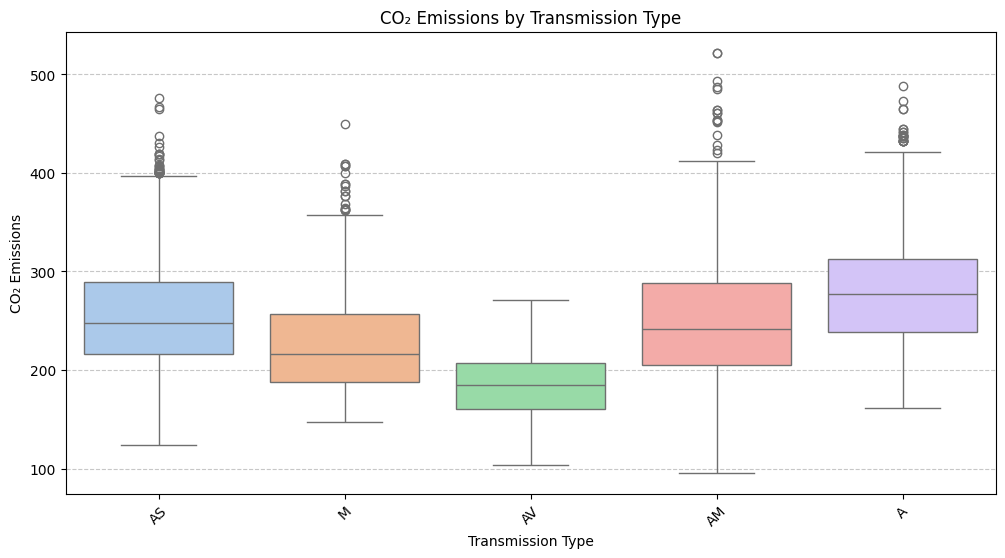

In [72]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='transmission', y='co2_emissions', data=df, palette='pastel')
plt.title('CO₂ Emissions by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('CO₂ Emissions')
transmission_original_labels = df['transmission'].unique()
plt.xticks(ticks=range(len(transmission_original_labels)), labels=transmission_original_labels, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**CO₂ Emissions by Fuel Type**

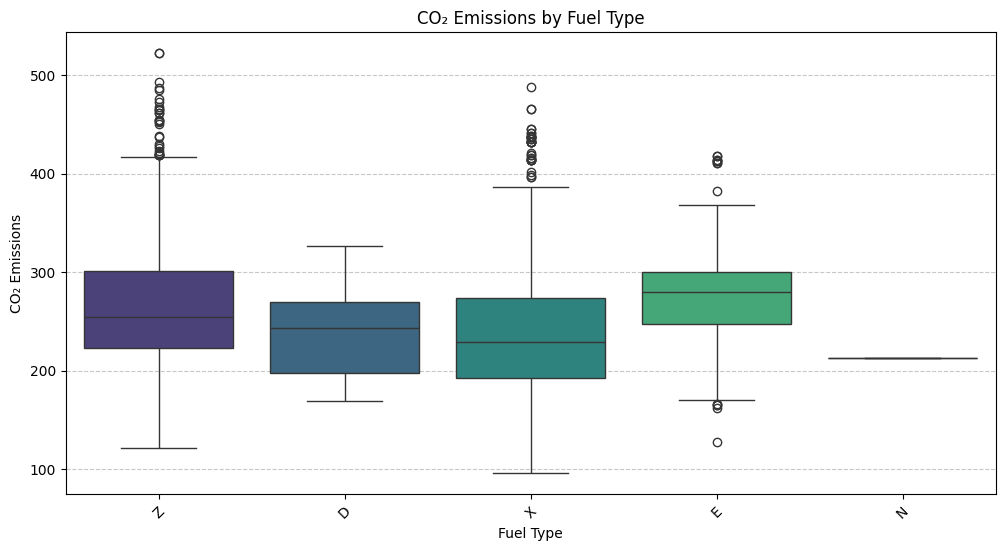

In [73]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='fuel_type', y='co2_emissions', data=df, palette='viridis')
plt.title('CO₂ Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('CO₂ Emissions')
fuel_type_original_labels = df['fuel_type'].unique()
plt.xticks(ticks=range(len(fuel_type_original_labels)), labels=fuel_type_original_labels, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**CO2 Emissions by Vehicle**

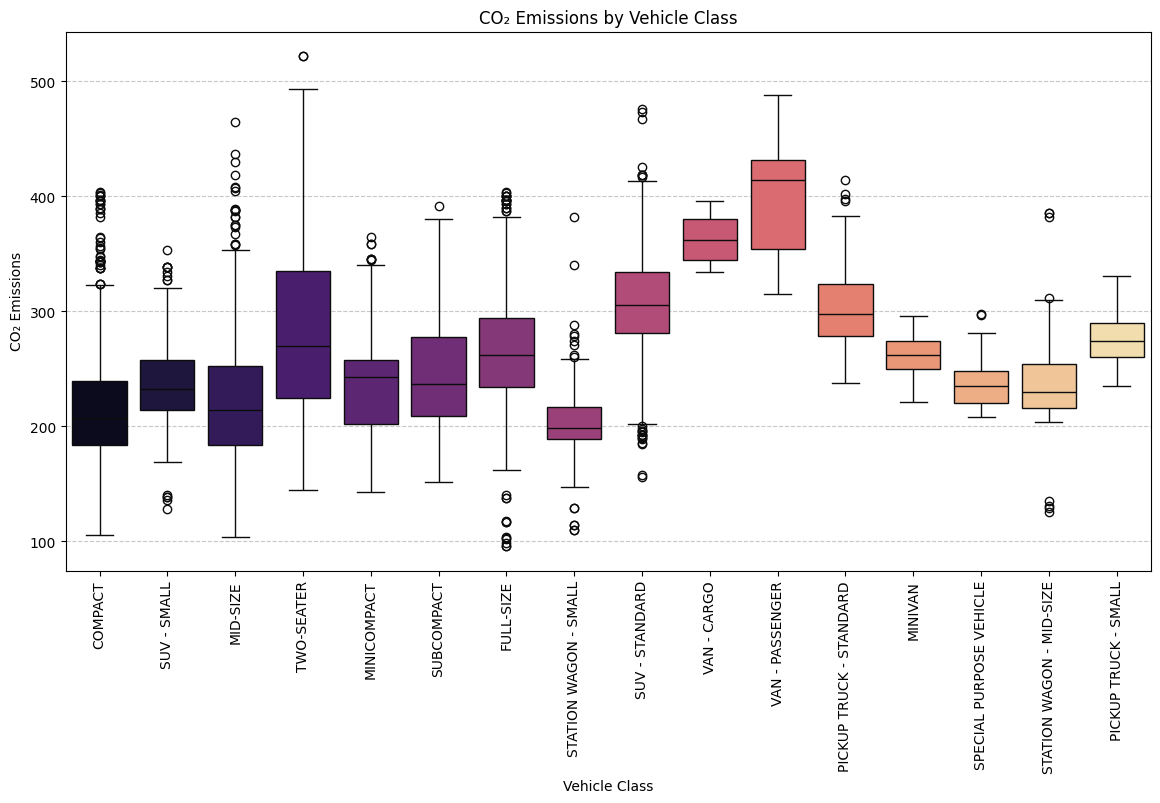

In [74]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='vehicle_class', y='co2_emissions', data=df, palette='magma')
plt.title('CO₂ Emissions by Vehicle Class')
plt.xlabel('Vehicle Class')
plt.ylabel('CO₂ Emissions')
vehicle_class_original_labels = df['vehicle_class'].unique()
plt.xticks(ticks=range(len(vehicle_class_original_labels)), labels=vehicle_class_original_labels, rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Vehicle Class Counts with Distinct Colors**

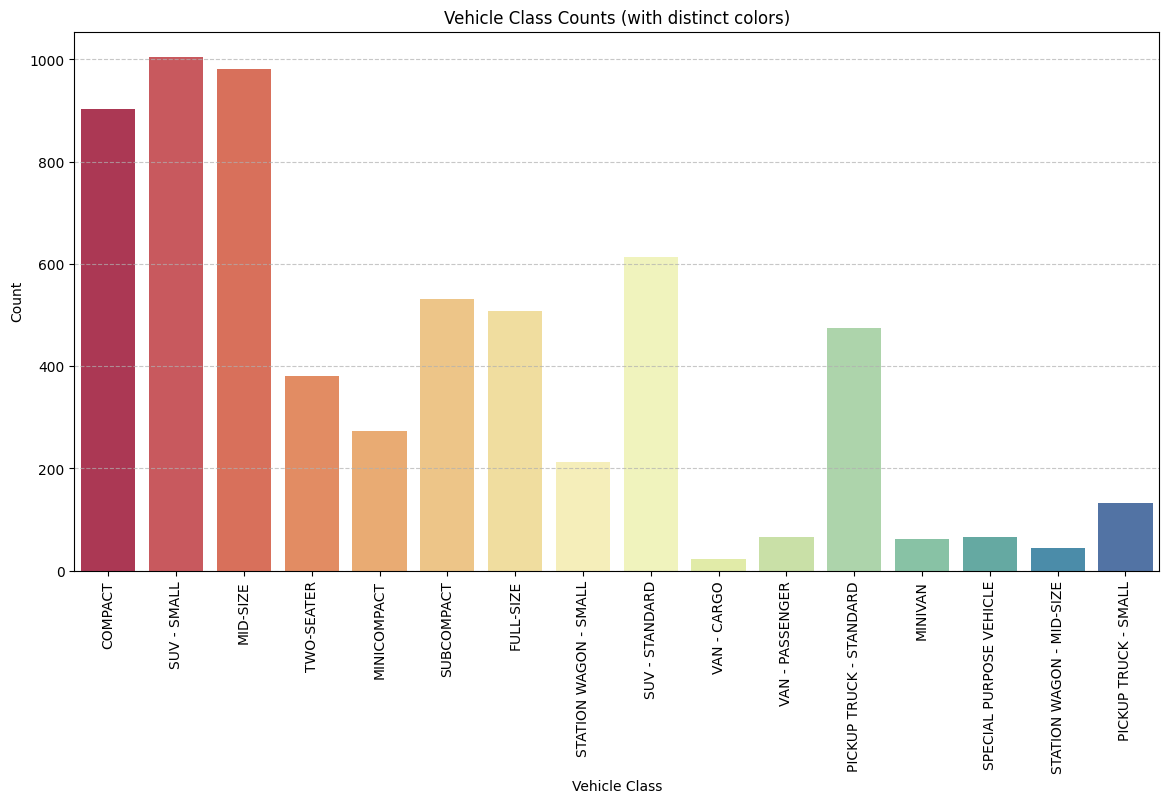

In [75]:
plt.figure(figsize=(14, 7))
sns.countplot(x='vehicle_class', data=df, palette='Spectral', hue='vehicle_class', legend=False)
plt.title('Vehicle Class Counts (with distinct colors)')
plt.xlabel('Vehicle Class')
plt.ylabel('Count')
vehicle_class_original_labels = df['vehicle_class'].unique()
plt.xticks(ticks=range(len(vehicle_class_original_labels)), labels=vehicle_class_original_labels, rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This distribution indicates that the model will be trained on a higher proportion of certain vehicle types. It's important to keep this in mind when evaluating model performance across different vehicle classes, especially for less frequent ones.

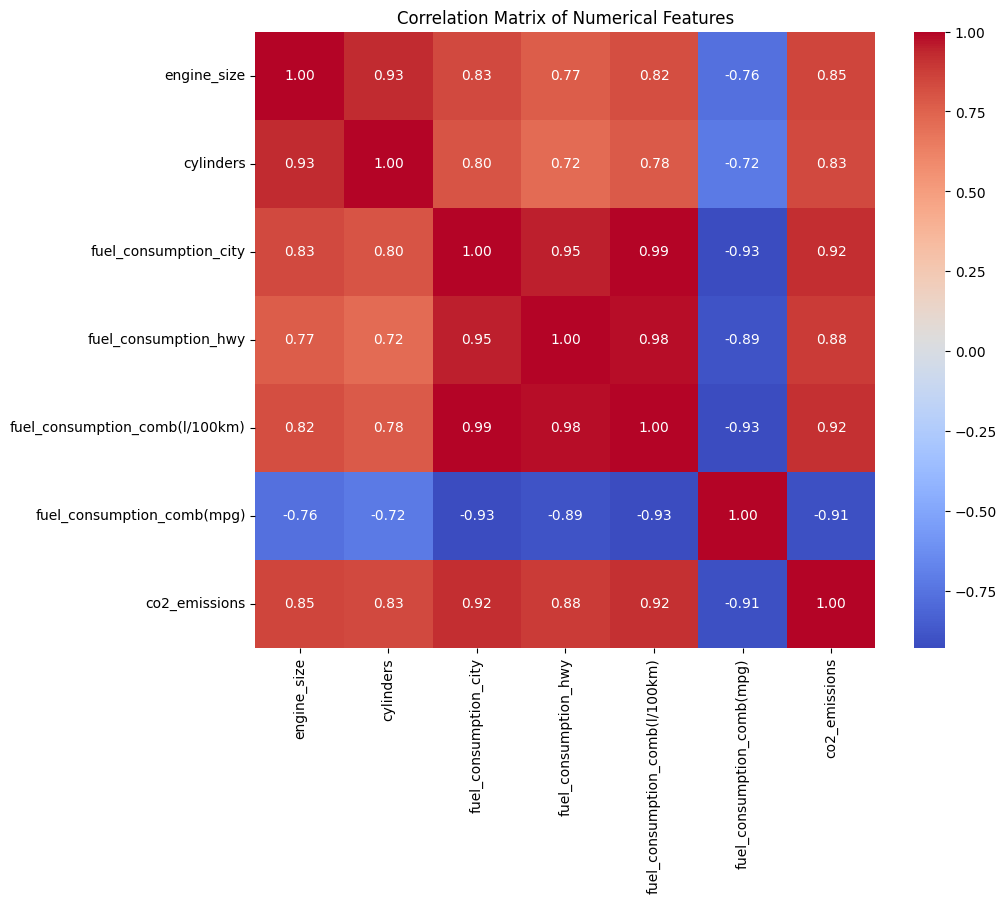

In [76]:
# Correlation matrix for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


This matrix highlights strong relationships between features and the target, but also indicates significant multicollinearity among the predictor variables. (This might be a concern for some linear models but less so for tree-based models)

## Data Preprocessing

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

df_processed = pd.read_csv('/content/drive/MyDrive/co2_emissions.csv', encoding='latin1')
df_processed.drop_duplicates(inplace=True)

df_processed = df_processed.drop('model', axis=1) #Drop the 'model' column due to high cardinality
categorical_features = ['make', 'vehicle_class', 'transmission', 'fuel_type'] # Identify categorical columns

# Create a ColumnTransformer to apply OneHotEncoder to categorical features and numerical features as they are.
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # Added sparse_output=False
    ],
    remainder='passthrough' # Keep other columns (numerical features and target)
)

X = df_processed.drop('co2_emissions', axis=1)
y = df_processed['co2_emissions']
X_transformed = preprocessor.fit_transform(X)

onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(categorical_features)
remainder_feature_names = [col for col in X.columns if col not in categorical_features]
all_feature_names = list(onehot_feature_names) + remainder_feature_names

X = pd.DataFrame(X_transformed, columns=all_feature_names)

print("Shape of X after One-Hot Encoding and dropping 'model':", X.shape)
display(X.head())

Shape of X after One-Hot Encoding and dropping 'model': (6273, 74)


,make_ACURA,make_ALFA ROMEO,make_ASTON MARTIN,make_AUDI,make_BENTLEY,make_BMW,make_BUGATTI,make_BUICK,make_CADILLAC,make_CHEVROLET,...,fuel_type_E,fuel_type_N,fuel_type_X,fuel_type_Z,engine_size,cylinders,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg)
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2.0,4.0,9.9,6.7,8.5,33.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2.4,4.0,11.2,7.7,9.6,29.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.5,4.0,6.0,5.8,5.9,48.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,3.5,6.0,12.7,9.1,11.1,25.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,3.5,6.0,12.1,8.7,10.6,27.0


the 'model' column was dropped due to high cardinality

### Handling Multicollinearity:

In [78]:
columns_to_drop_for_multicollinearity = [
    'fuel_consumption_city',
    'fuel_consumption_hwy',
    'fuel_consumption_comb(mpg)'
]

# Ensure these columns exist in X before dropping
existing_columns_to_drop = [col for col in columns_to_drop_for_multicollinearity if col in X.columns]

X_filtered = X.drop(columns=existing_columns_to_drop, axis=1)

print(f"Columns dropped for multicollinearity: {existing_columns_to_drop}")
print(f"Shape of X after handling multicollinearity: {X_filtered.shape}")

Columns dropped for multicollinearity: ['fuel_consumption_city', 'fuel_consumption_hwy', 'fuel_consumption_comb(mpg)']
Shape of X after handling multicollinearity: (6273, 71)


We have successfully removed highly correlated and redundant fuel consumption features (`fuel_consumption_city`, `fuel_consumption_hwy`, and `fuel_consumption_comb(mpg)`). This step simplifies the feature set by reducing multicollinearity, which can be particularly beneficial for the stability and interpretability of models. The remaining `fuel_consumption_comb(l/100km)` effectively captures the fuel efficiency aspect without the redundancy. The feature set `X` is now cleaner and potentially better suited for various modeling approaches.

### Outlier Treatment:

In [79]:
def cap_outliers_iqr(df_col):
    Q1 = df_col.quantile(0.25)
    Q3 = df_col.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Cap the outliers
    df_col_capped = df_col.clip(lower=lower_bound, upper=upper_bound)
    return df_col_capped

# Identify numerical columns in X_filtered that need outlier treatment
numerical_cols_for_outlier_treatment = [
    'engine_size',
    'cylinders',
    'fuel_consumption_comb(l/100km)'
]

# Apply outlier capping to X_filtered
for col in numerical_cols_for_outlier_treatment:
    if col in X_filtered.columns:
        X_filtered[col] = cap_outliers_iqr(X_filtered[col])
        print(f"Outliers in '{col}' capped using IQR method.")
    else:
        print(f"Warning: Column '{col}' not found in X_filtered. Skipping outlier treatment for this column.")

print("Shape of X_filtered after outlier treatment:", X_filtered.shape)
display(X_filtered.describe())

Outliers in 'engine_size' capped using IQR method.
Outliers in 'cylinders' capped using IQR method.
Outliers in 'fuel_consumption_comb(l/100km)' capped using IQR method.
Shape of X_filtered after outlier treatment: (6273, 71)


,make_ACURA,make_ALFA ROMEO,make_ASTON MARTIN,make_AUDI,make_BENTLEY,make_BMW,make_BUGATTI,make_BUICK,make_CADILLAC,make_CHEVROLET,...,transmission_AV,transmission_M,fuel_type_D,fuel_type_E,fuel_type_N,fuel_type_X,fuel_type_Z,engine_size,cylinders,fuel_consumption_comb(l/100km)
count,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,...,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000
mean,0.008130,0.003029,0.006217,0.041926,0.005579,0.079866,0.000319,0.014666,0.022477,0.082098,...,0.073011,0.162442,0.023434,0.052606,0.000159,0.483022,0.440778,3.155277,5.547425,10.984266
std,0.089807,0.054956,0.078609,0.200435,0.074493,0.271107,0.017854,0.120222,0.148242,0.274536,...,0.260176,0.368885,0.151289,0.223264,0.012626,0.499752,0.496520,1.345229,1.641213,2.822504
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.900000,3.000000,4.100000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000,8.900000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,10.600000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.700000,6.000000,12.700000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.250000,9.000000,18.400000


We have successfully applied the IQR-based capping method to treat outliers in `engine_size`, `cylinders`, and `fuel_consumption_comb(l/100km)`. By examining the descriptive statistics after this operation, we can see that extreme values have been constrained within more reasonable bounds.  The shape of `X_filtered` remains the same, as we modified existing values rather than removing rows or columns. This step contributes to a cleaner and more stable dataset for model training.

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, # Changed from X to X_filtered to use the preprocessed data
    y,
    test_size=0.2,
    random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (5018, 71)
X_test shape: (1255, 71)
y_train shape: (5018,)
y_test shape: (1255,)


### Feature Scaling


In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


### Target Variable Transformation

Given that the `co2_emissions` target variable was right-skewed, applying a logarithmic transformation can help normalize its distribution

In [82]:
import numpy as np
y_train_transformed = np.log1p(y_train)
y_test_transformed = np.log1p(y_test)

print("Target variable transformed successfully using log1p!")

Target variable transformed successfully using log1p!


Distribution of Transformed Target Variable

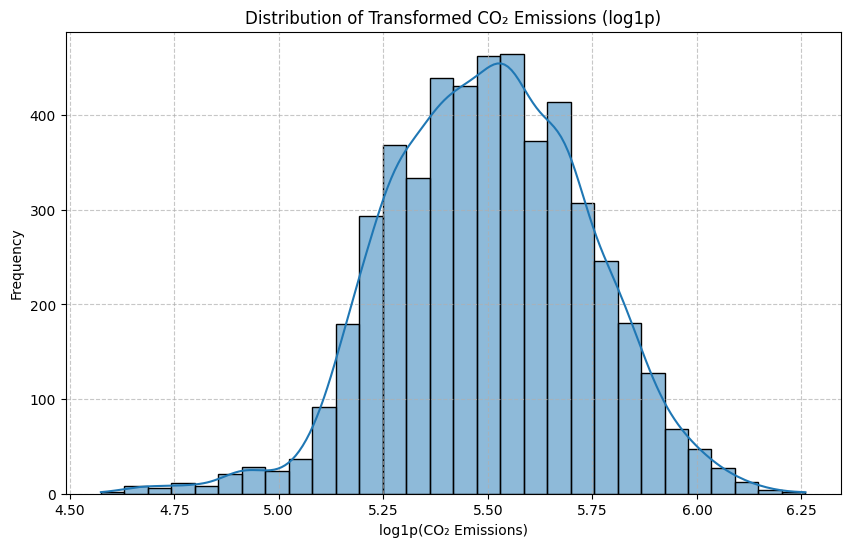

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(y_train_transformed, kde=True, bins=30)
plt.title('Distribution of Transformed CO₂ Emissions (log1p)')
plt.xlabel('log1p(CO₂ Emissions)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

the right-skewness has been significantly reduced, resulting in a distribution that is much closer to a normal distribution. This transformation can help improve the performance of models and models that assume normally distributed residuals, making them more robust and interpretable.

# Model Training and Evaluation

### Random Forest Regressor

In [125]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

models = {}

def evaluate_model(model, X_test_scaled, y_test_transformed, y_test_original):
    """Evaluates a given model and prints performance metrics."""
    y_pred_transformed = model.predict(X_test_scaled)

    y_pred_original = np.expm1(y_pred_transformed)

    if isinstance(y_test_original, pd.Series):
        y_test_original = y_test_original.values
    mae = mean_absolute_error(y_test_original, y_pred_original)
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, y_pred_original)
    print(f"\n--- {model.__class__.__name__} Evaluation (on original scale) ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2): {r2:.2f}")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.6)
    plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--')
    plt.title(f'{model.__class__.__name__}: Actual vs Predicted CO₂ Emissions')
    plt.xlabel('Actual CO₂ Emissions')
    plt.ylabel('Predicted CO₂ Emissions')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


--- RandomForestRegressor Evaluation (on original scale) ---
Mean Absolute Error (MAE): 2.22
Mean Squared Error (MSE): 11.35
Root Mean Squared Error (RMSE): 3.37
R-squared (R2): 1.00


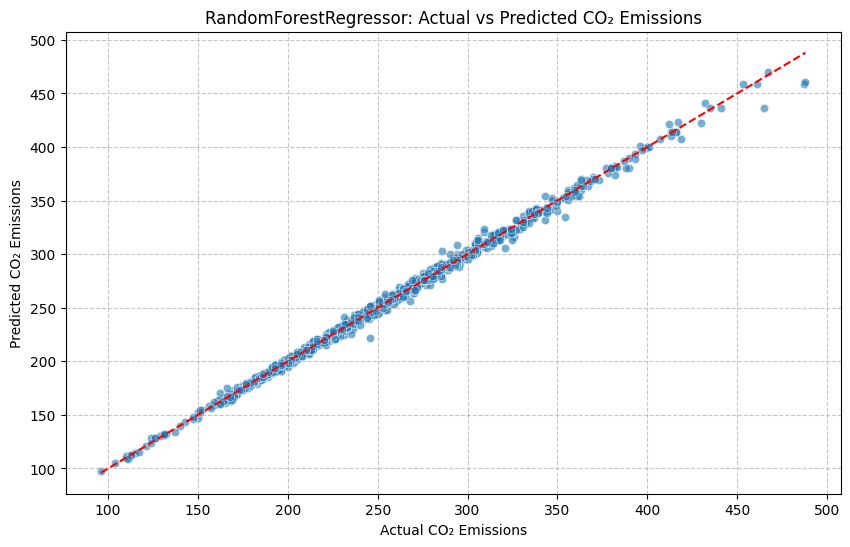

In [126]:
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train_scaled, y_train_transformed)

models['Random_Forest'] = random_forest_model # Add untuned Random Forest to models dictionary

evaluate_model(random_forest_model, X_test_scaled, y_test_transformed, y_test)

Hyperparameter tuning for Random Forest Regressor

In [127]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_base = RandomForestRegressor(random_state=42)
random_search_rf = RandomizedSearchCV(estimator=rf_base,param_distributions=param_dist_rf,n_iter=50,cv=3,verbose=2,random_state=42,
                                      n_jobs=-1, # Use all available cores
                                      scoring='neg_mean_squared_error')


random_search_rf.fit(X_train_scaled, y_train_transformed)

print(f"\nBest parameters found for Random Forest: {random_search_rf.best_params_}")
print(f"Best score (negative MSE) for Random Forest: {random_search_rf.best_score_:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best parameters found for Random Forest: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': True}
Best score (negative MSE) for Random Forest: -0.0007


The Random Forest Regressor demonstrated excellent performance, achieving an R-squared value of 1.00. With a low Mean Absolute Error (MAE) of 2.22 and Root Mean Squared Error (RMSE) of 3.37, it provides highly accurate predictions.

### XGBoost Regressor

In [128]:
from xgboost import XGBRegressor
import time


In [129]:
# --- XGBoost Regressor ---
xgb = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=42)
xgb.fit(X_train_scaled, y_train_transformed)
models['XGBoost'] = xgb
print("All models trained successfully!")

All models trained successfully!


In [130]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
results = []
for name, model in models.items():
    y_pred_log = model.predict(X_test_scaled)
    y_pred = np.expm1(y_pred_log)
    y_true = y_test  # original scale, already available
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    results.append({'Model': name,'MAE': round(mae, 3),'RMSE': round(rmse, 3),'R2 Score': round(r2, 4)})
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
print("Model Comparison:")
display(results_df)

Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Random_Forest,2.215,3.369,0.9968
1,XGBoost,2.420,3.762,0.9961


Hyperparameter Tuning for XGBoost Regressor

In [131]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4]
}
xgb_base = XGBRegressor(random_state=42)
random_search_xgb = RandomizedSearchCV(estimator=xgb_base,param_distributions=param_dist_xgb,n_iter=50, cv=3, verbose=2,random_state=42,n_jobs=-1,
    scoring='neg_mean_squared_error' )

random_search_xgb.fit(X_train_scaled, y_train_transformed)

print(f"\nBest parameters found for XGBoost: {random_search_xgb.best_params_}")
print(f"Best score (negative MSE) for XGBoost: {random_search_xgb.best_score_:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best parameters found for XGBoost: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}
Best score (negative MSE) for XGBoost: -0.0002


### ExtraTrees Regressor


--- ExtraTreesRegressor Evaluation (on original scale) ---
Mean Absolute Error (MAE): 2.26
Mean Squared Error (MSE): 14.20
Root Mean Squared Error (RMSE): 3.77
R-squared (R2): 1.00


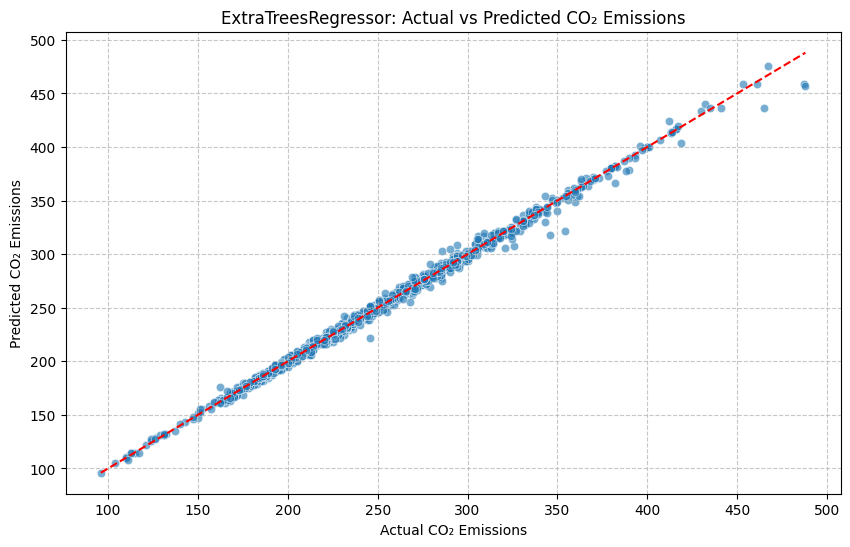

In [132]:
from sklearn.ensemble import ExtraTreesRegressor
# Initialize and train
extra_trees_model = ExtraTreesRegressor(random_state=42)
extra_trees_model.fit(X_train_scaled, y_train_transformed)
evaluate_model(extra_trees_model, X_test_scaled, y_test_transformed, y_test)
models['ExtraTrees'] = extra_trees_model

Hyperparameter Tuning for ExtraTrees Regressor

In [133]:
param_dist_et = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False] }

et_base = ExtraTreesRegressor(random_state=42)
random_search_et = RandomizedSearchCV(estimator=et_base,param_distributions=param_dist_et,n_iter=50,cv=3,verbose=2,random_state=42,n_jobs=-1,scoring='neg_mean_squared_error')
random_search_et.fit(X_train_scaled, y_train_transformed)

print(f"\nBest parameters found for ExtraTrees: {random_search_et.best_params_}")
print(f"Best score (negative MSE) for ExtraTrees: {random_search_et.best_score_:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best parameters found for ExtraTrees: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': True}
Best score (negative MSE) for ExtraTrees: -0.0009


### Train Best Parameters and Re-evaluate All Models

In [134]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models['Random_Forest_Tuned'] = random_search_rf.best_estimator_
models['XGBoost_Tuned'] = random_search_xgb.best_estimator_
models['ExtraTrees_Tuned'] = random_search_et.best_estimator_

results = []
for name, model in models.items():
    y_pred_log = model.predict(X_test_scaled)
    y_pred = np.expm1(y_pred_log)
    y_true = y_test

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    results.append({'Model': name, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2 Score': round(r2, 4)})

results_df_all_tuned = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

In [135]:
display(results_df_all_tuned)

,Model,MAE,RMSE,R2 Score
0,Random_Forest,2.215,3.369,0.9968
1,XGBoost,2.420,3.762,0.9961
2,ExtraTrees,2.255,3.768,0.9960
3,XGBoost_Tuned,2.631,3.777,0.9960
4,Random_Forest_Tuned,3.296,5.489,0.9916
5,ExtraTrees_Tuned,3.654,5.984,0.9900


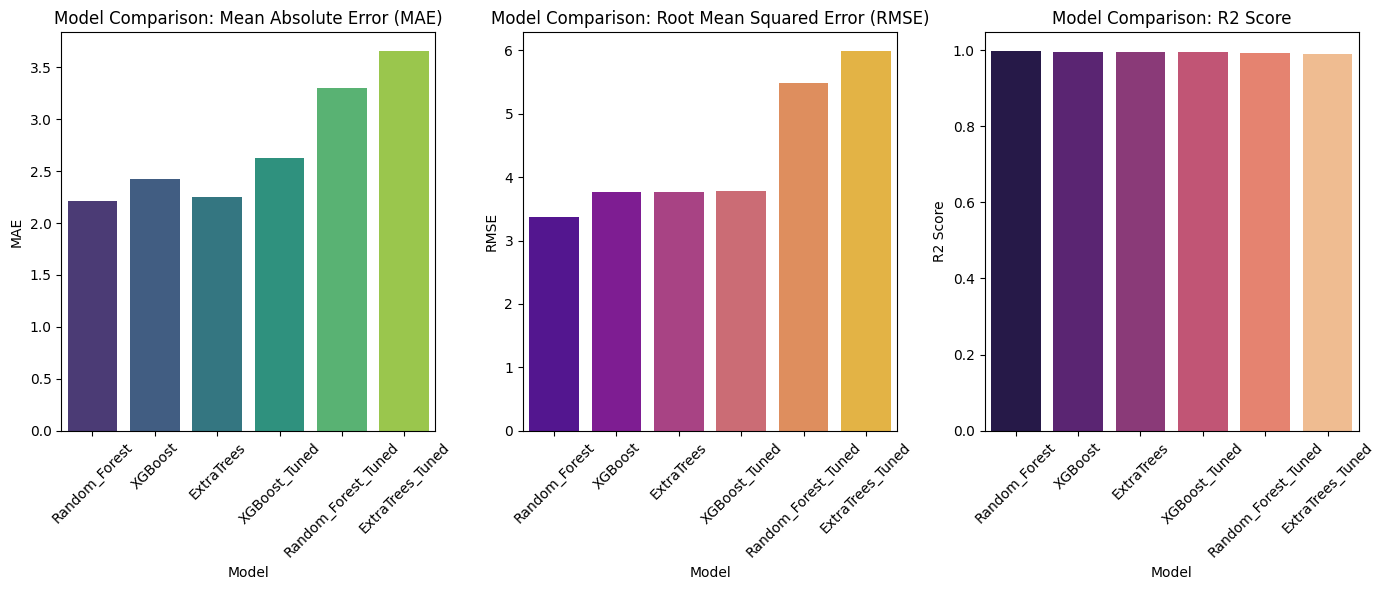

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Bar chart for MAE
sns.barplot(x='Model', y='MAE', data=results_df_all_tuned, ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: Mean Absolute Error (MAE)')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart for RMSE
sns.barplot(x='Model', y='RMSE', data=results_df_all_tuned, ax=axes[1], palette='plasma')
axes[1].set_title('Model Comparison: Root Mean Squared Error (RMSE)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

# Bar chart for R2 Score
sns.barplot(x='Model', y='R2 Score', data=results_df_all_tuned, ax=axes[2], palette='magma')
axes[2].set_title('Model Comparison: R2 Score')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('R2 Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [137]:
print("\nModel Comparison before & after tuning):")
display(results_df_all_tuned)


Model Comparison before & after tuning):


,Model,MAE,RMSE,R2 Score
0,Random_Forest,2.215,3.369,0.9968
1,XGBoost,2.420,3.762,0.9961
2,ExtraTrees,2.255,3.768,0.9960
3,XGBoost_Tuned,2.631,3.777,0.9960
4,Random_Forest_Tuned,3.296,5.489,0.9916
5,ExtraTrees_Tuned,3.654,5.984,0.9900


Identify the best Model

In [138]:
best_idx = results_df_all_tuned['R2 Score'].idxmax()
best_model_name = results_df_all_tuned.loc[best_idx, 'Model']
best_model = models[best_model_name]
print(f"Best performing tuned model: {best_model_name}")

Best performing tuned model: Random_Forest


Visualizing performance for the best model: Random_Forest


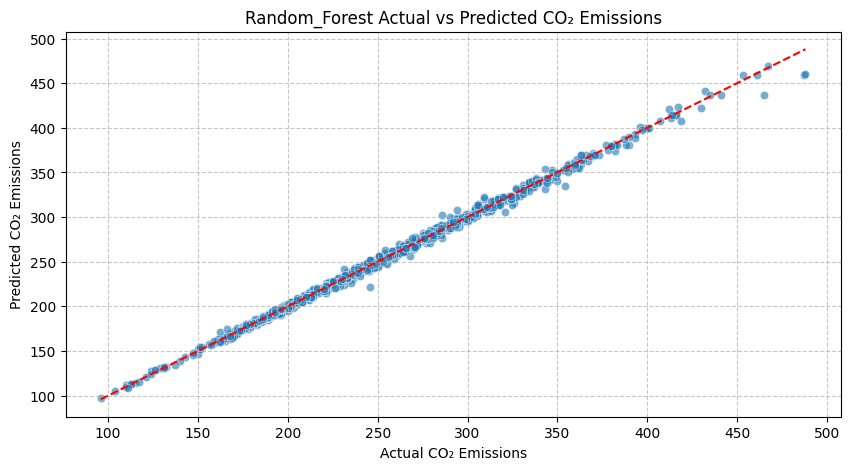

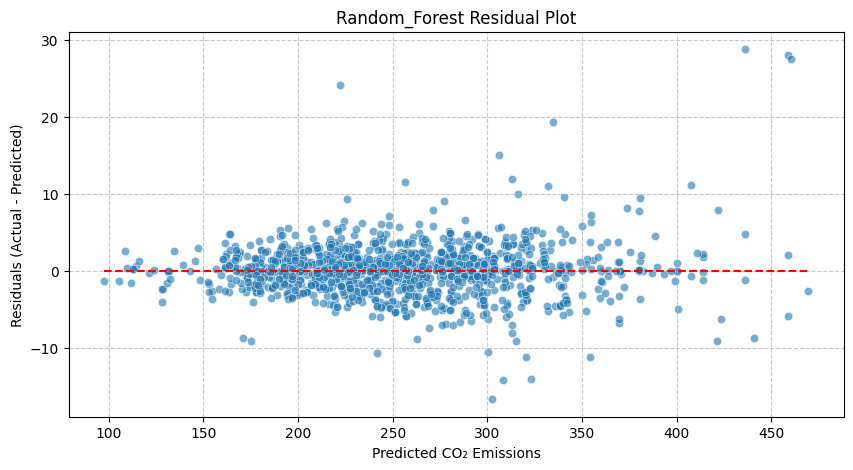

In [139]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def plot_actual_vs_predicted(model, X_test_scaled, y_test_transformed, y_test_original, title_prefix=""):
    """Plots actual vs predicted values."""
    y_pred_transformed = model.predict(X_test_scaled)
    y_pred_original = np.expm1(y_pred_transformed)

    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.6, palette='viridis')
    plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--')
    plt.title(f'{title_prefix} Actual vs Predicted CO₂ Emissions')
    plt.xlabel('Actual CO₂ Emissions')
    plt.ylabel('Predicted CO₂ Emissions')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def plot_residuals(model, X_test_scaled, y_test_transformed, y_test_original, title_prefix=""):
    """Plots residuals."""
    y_pred_transformed = model.predict(X_test_scaled)
    y_pred_original = np.expm1(y_pred_transformed)

    residuals = y_test_original - y_pred_original

    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=y_pred_original, y=residuals, alpha=0.6, palette='viridis')
    plt.hlines(0, xmin=y_pred_original.min(), xmax=y_pred_original.max(), colors='r', linestyles='--')
    plt.title(f'{title_prefix} Residual Plot')
    plt.xlabel('Predicted CO₂ Emissions')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
print(f"Visualizing performance for the best model: {best_model_name}")
plot_actual_vs_predicted(best_model, X_test_scaled, y_test_transformed, y_test, title_prefix=best_model_name)
plot_residuals(best_model, X_test_scaled, y_test_transformed, y_test, title_prefix=best_model_name)

## Post-Training Analysis: Feature Importance


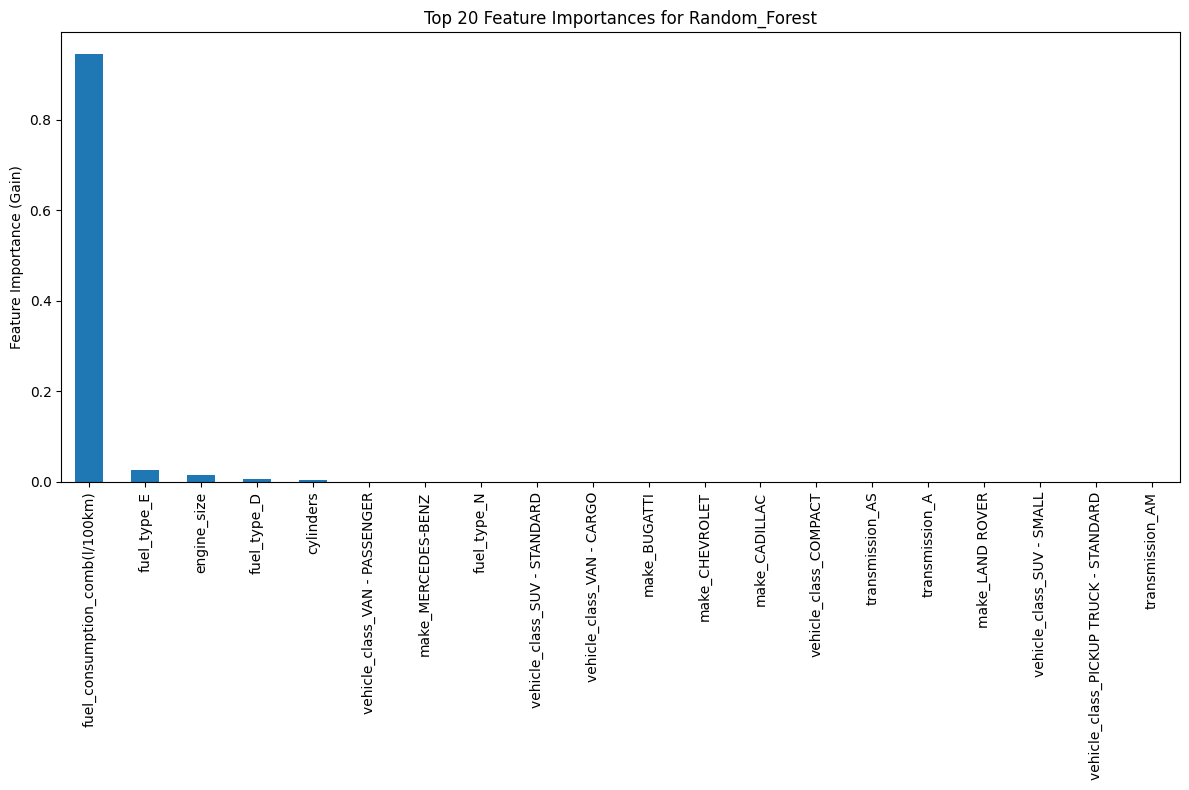

Top 20 Most Important Features:
fuel_consumption_comb(l/100km)           0.945796
fuel_type_E                              0.026220
engine_size                              0.014514
fuel_type_D                              0.006334
cylinders                                0.003399
vehicle_class_VAN - PASSENGER            0.000862
make_MERCEDES-BENZ                       0.000327
fuel_type_N                              0.000304
vehicle_class_SUV - STANDARD             0.000193
vehicle_class_VAN - CARGO                0.000163
make_BUGATTI                             0.000141
make_CHEVROLET                           0.000129
make_CADILLAC                            0.000109
vehicle_class_COMPACT                    0.000107
transmission_AS                          0.000106
transmission_A                           0.000103
make_LAND ROVER                          0.000096
vehicle_class_SUV - SMALL                0.000093
vehicle_class_PICKUP TRUCK - STANDARD    0.000082
transmission_AM   

In [140]:
importances = best_model.feature_importances_
feature_names = X_filtered.columns

model_importances = pd.Series(importances, index=feature_names)
model_importances = model_importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
model_importances.head(20).plot.bar(ax=ax)
ax.set_title(f"Top 20 Feature Importances for {best_model_name}")
ax.set_ylabel("Feature Importance (Gain)")
plt.tight_layout()
plt.show()

print("Top 20 Most Important Features:")
print(model_importances.head(20))

## Model Saving for Deployment

In [141]:
import joblib

model_path = 'best_xgboost_model.joblib'
scaler_path = 'scaler.joblib'
preprocessor_path = 'preprocessor.joblib'

joblib.dump(best_model, model_path)
print(f"Best model ({best_model_name}) saved to {model_path}") #save model

joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}") #save scaler

joblib.dump(preprocessor, preprocessor_path)
print(f"Preprocessor saved to {preprocessor_path}") #save processor

print("All necessary components for deployment have been saved!")

Best model (Random_Forest) saved to best_xgboost_model.joblib
Scaler saved to scaler.joblib
Preprocessor saved to preprocessor.joblib
All necessary components for deployment have been saved!
